In [25]:
from transformer_block import TransformerBlock
from tokenization_and_embedding import TokenAndPositionEmbedding
import tensorflow as tf
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import umap
import sentencepiece as spm

import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.model_selection import train_test_split

/home/duncanskilton/tf-gpu/lib/python3.10/site-packages/keras/src/layers/layer.py:421: UserWarning:

`build()` was called on layer 'transformer_block_32', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.

/home/duncanskilton/tf-gpu/lib/python3.10/site-packages/keras/src/layers/layer.py:421: UserWarning:

`build()` was called on layer 'transformer_block_33', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.



326/326 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step
(41681, 128)
326/326 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step
(41681, 128)


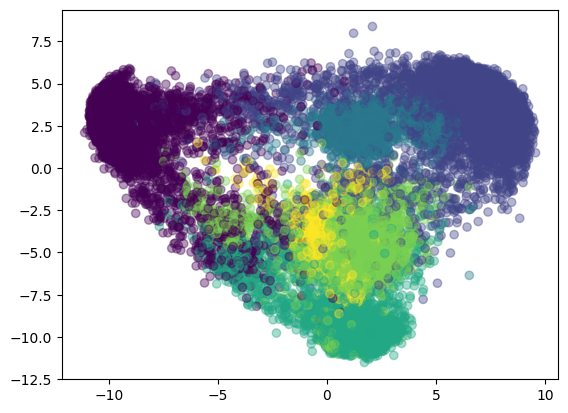

In [36]:
SENTENCE_VECTORS = 32000

df = pd.read_parquet("data.parquet")

X = df["text"].astype(str)
y = df["label"].astype(int)

emotion_map = {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'} 
df['emotion'] = df['label'].map(emotion_map)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

model = tf.keras.models.load_model(
    "emotion_transformer.keras",
    custom_objects={
        "TokenAndPositionEmbedding": TokenAndPositionEmbedding, 
        "TransformerBlock": TransformerBlock
    }
)

embedding_layer = next(l for l in model.layers if isinstance(l, TokenAndPositionEmbedding))
embeddings = embedding_layer.get_weights()[0]
# print(embeddings.shape)

feature_model = tf.keras.Model(
    inputs=model.input,
    outputs=model.layers[-3].output
)

def encode_for_transformer(sp, texts, max_len=128):
    input_ids = []
    masks = []

    pad_id = sp.pad_id()

    for text in texts:
        ids = sp.encode(text.strip(), out_type=int)[:max_len]
        mask = [1]*len(ids)

        while len(ids) < max_len:
            ids.append(pad_id)
            mask.append(0)

        input_ids.append(ids)
        masks.append(mask)

    return (
        np.array(input_ids, dtype=np.int32),
        np.array(masks, dtype=np.int32)
    )

sp_bpe = spm.SentencePieceProcessor()
sp_bpe.load("m_bpe.model")

X_test_ids, X_test_mask = encode_for_transformer(
    sp_bpe,
    X_test.tolist()
)

test_data = tf.data.Dataset.from_tensor_slices(
    ((X_test_ids, X_test_mask), y_test.values)
).batch(128)

sentence_vectors = feature_model.predict(test_data)
print(sentence_vectors.shape)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(sentence_vectors)

plt.scatter(X_pca[:,0], X_pca[:,1], c=y_test, alpha=0.4)

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(sentence_vectors[:SENTENCE_VECTORS])

reducer = umap.UMAP(n_components=2, min_dist=0.1)
X_umap = reducer.fit_transform(sentence_vectors[:SENTENCE_VECTORS])

lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(sentence_vectors, y_test)

feature_model = tf.keras.Model(
    inputs=model.input,
    outputs=model.layers[-3].output
)

sentence_vectors = feature_model.predict(test_data)
print(sentence_vectors.shape)

In [37]:
def save_projection_html(X_2d, y, emotion_map, title, out_html):
    """
    X_2d: (n, 2) array
    y:    (n,) labels (ints)
    """
    df_plot = pd.DataFrame({
        "x": X_2d[:, 0],
        "y": X_2d[:, 1],
        "label": y.astype(int),
        "emotion": [emotion_map[int(i)] for i in y.astype(int)]
    })

    fig = px.scatter(
        df_plot,
        x="x",
        y="y",
        color="emotion",
        hover_data=["label", "emotion"],
        title=title
    )

    fig.update_traces(marker=dict(size=5, opacity=0.6))
    fig.write_html(out_html, include_plotlyjs="cdn")
    print(f"Saved: {out_html}")
    
y_test_np = y_test.to_numpy()

save_projection_html(
    X_pca,
    y_test_np,
    emotion_map,
    title="PCA of Transformer Sentence Vectors (Test Set)",
    out_html=f"{SENTENCE_VECTORS}_pca_sentence_vectors.html"
)

save_projection_html(
    X_tsne,
    y_test_np[:SENTENCE_VECTORS],
    emotion_map,
    title=f"t-SNE of Transformer Sentence Vectors (First {SENTENCE_VECTORS} Test Samples)",
    out_html=f"{SENTENCE_VECTORS}_tsne_sentence_vectors.html"
)

save_projection_html(
    X_umap[:, :2],
    y_test_np[:SENTENCE_VECTORS],
    emotion_map,
    title=f"UMAP (first 2 dims) of Transformer Sentence Vectors (First {SENTENCE_VECTORS} Test Samples)",
    out_html=f"{SENTENCE_VECTORS}_umap_sentence_vectors.html"
)

save_projection_html(
    X_umap[:, :2],
    y_test_np[:SENTENCE_VECTORS],
    emotion_map,
    title=f"UMAP (first 2 dims) of Transformer Sentence Vectors (First {SENTENCE_VECTORS} Test Samples)",
    out_html=f"{SENTENCE_VECTORS}_umap_sentence_vectors.html"
)

Saved: 32000_pca_sentence_vectors.html
Saved: 32000_tsne_sentence_vectors.html
Saved: 32000_umap_sentence_vectors.html
Saved: 32000_umap_sentence_vectors.html
